# Comprensión y análisis exploratorio de datos (EDA)

**Objetivo:** comprender la calidad, distribución y relaciones de la base antes de crear un modelo.

El análisis se divide en:

1. Exploración inicial y calidad.
2. Análisis univariable: una variable por vez.
3. Análisis bivariable: relación entre dos variables.
4. Análisis multivariable: varias variables simultáneamente.

> En esta etapa identificamos problemas y formulamos hipótesis. La imputación y transformación definitiva corresponde a ingeniería de características.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

posibles_rutas = [Path("Base_de_datos.csv"), Path("../Base_de_datos.csv")]
ruta_datos = next((ruta for ruta in posibles_rutas if ruta.exists()), None)
if ruta_datos is None:
    raise FileNotFoundError("No se encontró Base_de_datos.csv")

df = pd.read_csv(ruta_datos, parse_dates=["fecha_prestamo"])
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 10,763 filas x 23 columnas


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


## 1. Exploración inicial y descripción

In [2]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(dropna=True),
})
resumen.sort_values("nulos_%", ascending=False)

,tipo,nulos,nulos_%,unicos
tendencia_ingresos,str,2932,27.24,46
promedio_ingresos_datacredito,float64,2930,27.22,5309
saldo_mora_codeudor,float64,590,5.48,4
saldo_principal,float64,405,3.76,8647
saldo_mora,float64,156,1.45,55
saldo_total,float64,156,1.45,8858
puntaje_datacredito,float64,6,0.06,315
salario_cliente,int64,0,0.00,1385
tipo_laboral,str,0,0.00,2
edad_cliente,int64,0,0.00,54


In [3]:
print(f"Duplicados exactos: {df.duplicated().sum()}")
display(df.describe(include="number").T)
display(df.describe(include=["object", "datetime"]).T)

Duplicados exactos: 0


,count,mean,std,min,25%,50%,75%,max
tipo_credito,"10,763.00",5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80"
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00


C:\Users\mchap\AppData\Local\Temp\ipykernel_23612\3579531679.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object", "datetime"]).T)


,count,unique,top,freq,mean,min,25%,50%,75%,max
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN
tendencia_ingresos,7831,46,Creciente,5294,NaN,NaN,NaN,NaN,NaN,NaN


### Revisión de faltantes

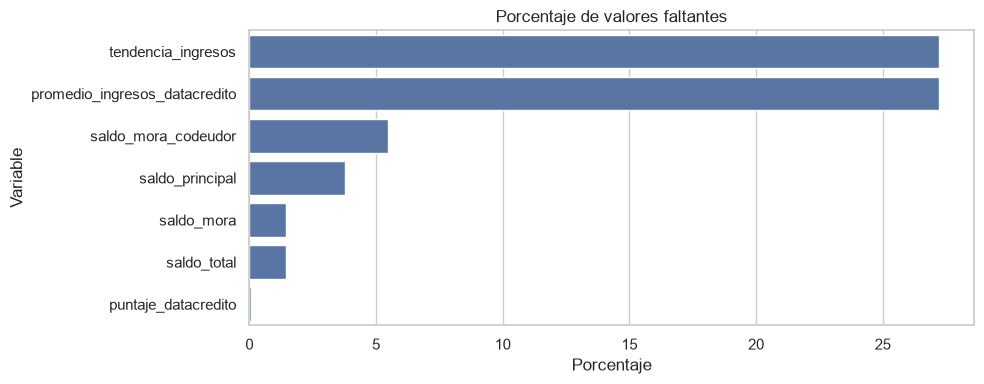

,porcentaje_nulos
tendencia_ingresos,27.24
promedio_ingresos_datacredito,27.22
saldo_mora_codeudor,5.48
saldo_principal,3.76
saldo_mora,1.45
saldo_total,1.45
puntaje_datacredito,0.06


In [4]:
faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

plt.figure(figsize=(10, 4))
sns.barplot(x=faltantes.values, y=faltantes.index, color="#4C72B0")
plt.title("Porcentaje de valores faltantes")
plt.xlabel("Porcentaje")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

faltantes.rename("porcentaje_nulos").to_frame()

### Controles de valores posiblemente inconsistentes

In [5]:
controles = {
    "edades_mayores_a_100": int((df["edad_cliente"] > 100).sum()),
    "salarios_iguales_a_0": int((df["salario_cliente"] == 0).sum()),
    "puntaje_datacredito_negativo": int((df["puntaje_datacredito"] < 0).sum()),
    "categorias_tipo_credito": sorted(df["tipo_credito"].dropna().unique().tolist()),
}
controles

{'edades_mayores_a_100': 150,
 'salarios_iguales_a_0': 24,
 'puntaje_datacredito_negativo': 1,
 'categorias_tipo_credito': [4, 6, 7, 9, 10, 68]}

In [6]:
# Esta variable debería contener categorías de tendencia, pero también aparecen números.
df["tendencia_ingresos"].astype("string").value_counts(dropna=False).head(15)

tendencia_ingresos
Creciente      5294
<NA>           2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
Name: count, dtype: int64[pyarrow]

**Interpretación inicial:** hay valores que deben validarse con el dueño del dato, no borrarse automáticamente. Por ejemplo, edades superiores a 100, salarios extremos, códigos poco frecuentes de crédito y números dentro de `tendencia_ingresos`.

## 2. Análisis univariable

### Variable objetivo: `Pago_atiempo`

,cantidad,porcentaje
Pago_atiempo,,
0,511,4.75
1,10252,95.25


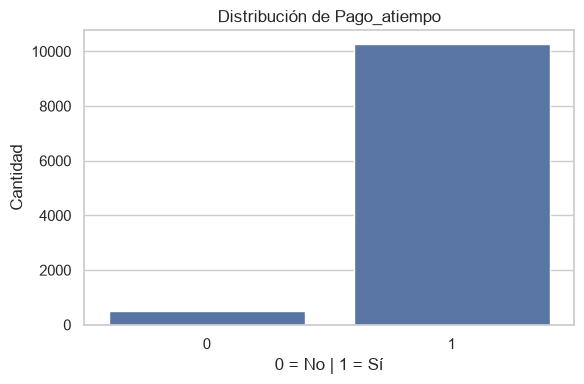

In [7]:
conteo_objetivo = df["Pago_atiempo"].value_counts().sort_index()
porcentaje_objetivo = (df["Pago_atiempo"].value_counts(normalize=True).sort_index() * 100).round(2)
display(pd.DataFrame({"cantidad": conteo_objetivo, "porcentaje": porcentaje_objetivo}))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Pago_atiempo", color="#4C72B0")
ax.set(title="Distribución de Pago_atiempo", xlabel="0 = No | 1 = Sí", ylabel="Cantidad")
plt.tight_layout()
plt.show()

La clase objetivo está desbalanceada. Esto será importante al dividir los datos y evaluar modelos: la exactitud (`accuracy`) por sí sola podría resultar engañosa.

### Variables numéricas

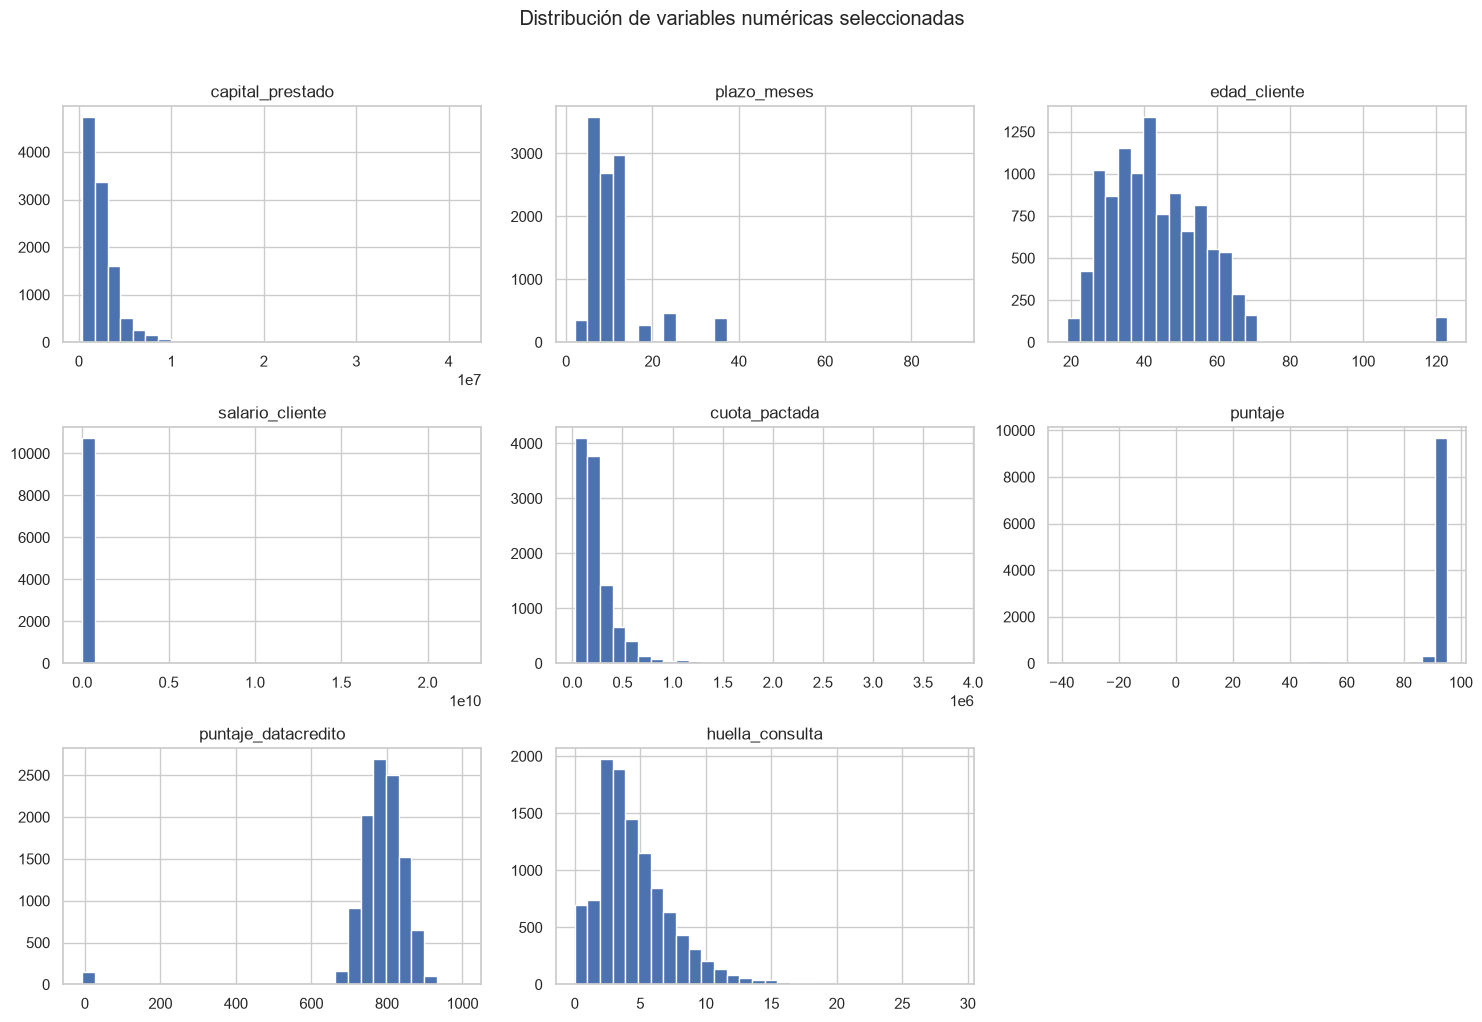

In [8]:
variables_numericas = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "cuota_pactada", "puntaje", "puntaje_datacredito", "huella_consulta",
]

df[variables_numericas].hist(figsize=(15, 10), bins=30, color="#4C72B0", edgecolor="white")
plt.suptitle("Distribución de variables numéricas seleccionadas", y=1.02)
plt.tight_layout()
plt.show()

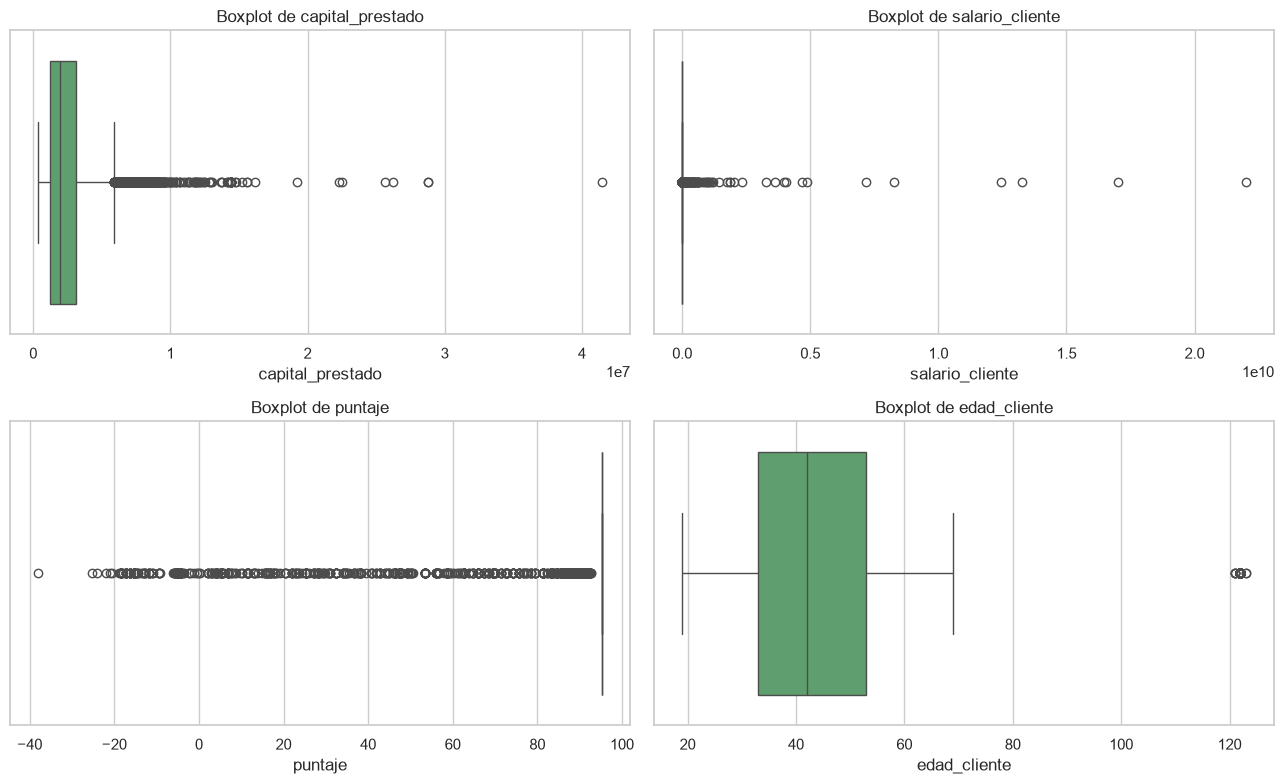

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for variable, ax in zip(["capital_prestado", "salario_cliente", "puntaje", "edad_cliente"], axes.flat):
    sns.boxplot(x=df[variable], ax=ax, color="#55A868")
    ax.set_title(f"Boxplot de {variable}")
plt.tight_layout()
plt.show()

### Variables categóricas

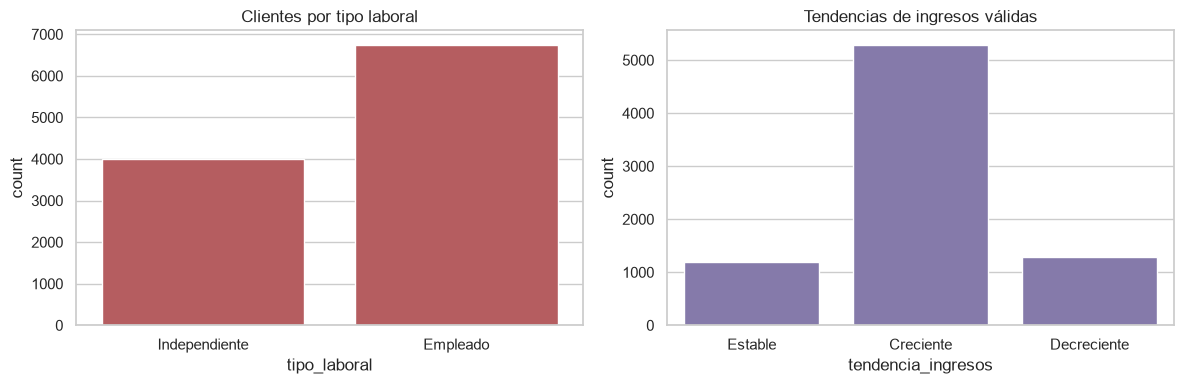

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="tipo_laboral", ax=axes[0], color="#C44E52")
axes[0].set_title("Clientes por tipo laboral")

tendencias_validas = df[df["tendencia_ingresos"].isin(["Creciente", "Estable", "Decreciente"])]
sns.countplot(data=tendencias_validas, x="tendencia_ingresos", ax=axes[1], color="#8172B2")
axes[1].set_title("Tendencias de ingresos válidas")
plt.tight_layout()
plt.show()

## 3. Análisis bivariable

### Variables categóricas frente al objetivo

In [11]:
tasa_laboral = (
    df.groupby("tipo_laboral", observed=True)["Pago_atiempo"]
      .agg(cantidad="size", tasa_pago_a_tiempo="mean")
      .sort_values("tasa_pago_a_tiempo")
)
tasa_laboral["tasa_pago_a_tiempo_%"] = (tasa_laboral["tasa_pago_a_tiempo"] * 100).round(2)
tasa_laboral

,cantidad,tasa_pago_a_tiempo,tasa_pago_a_tiempo_%
tipo_laboral,,,
Independiente,4009,0.94,94.49
Empleado,6754,0.96,95.71


In [12]:
tabla_tendencia = (
    tendencias_validas.groupby("tendencia_ingresos", observed=True)["Pago_atiempo"]
    .agg(cantidad="size", tasa_pago_a_tiempo="mean")
    .sort_values("tasa_pago_a_tiempo")
)
tabla_tendencia["tasa_pago_a_tiempo_%"] = (tabla_tendencia["tasa_pago_a_tiempo"] * 100).round(2)
tabla_tendencia

,cantidad,tasa_pago_a_tiempo,tasa_pago_a_tiempo_%
tendencia_ingresos,,,
Decreciente,1291,0.94,93.73
Estable,1188,0.95,95.37
Creciente,5294,0.96,96.09


### Variables numéricas frente al objetivo

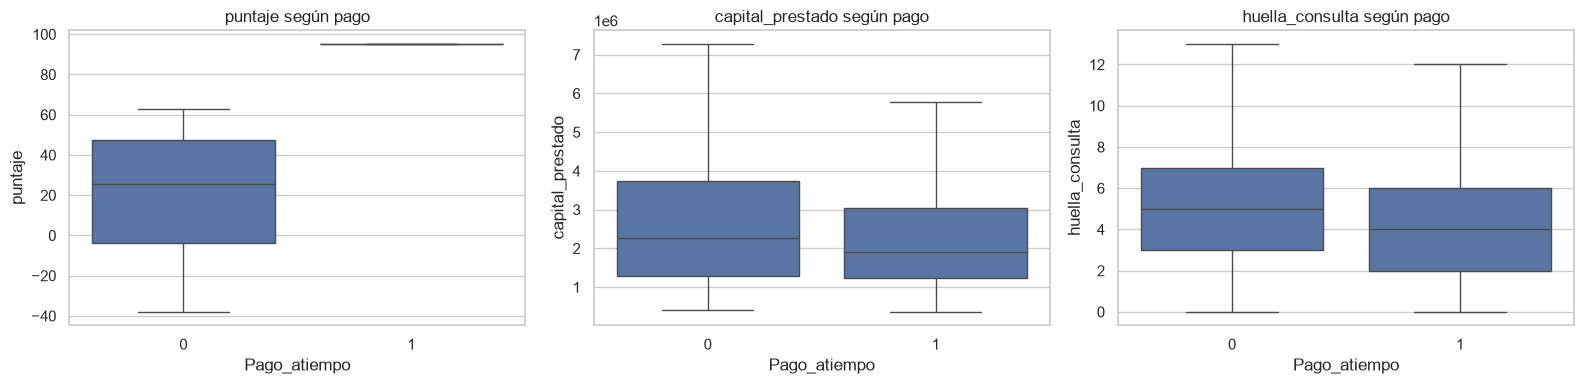

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for variable, ax in zip(["puntaje", "capital_prestado", "huella_consulta"], axes):
    sns.boxplot(data=df, x="Pago_atiempo", y=variable, ax=ax, showfliers=False)
    ax.set_title(f"{variable} según pago")
plt.tight_layout()
plt.show()

In [14]:
correlacion_objetivo = (
    df.select_dtypes(include="number")
      .corr()["Pago_atiempo"]
      .drop("Pago_atiempo")
      .sort_values(key=abs, ascending=False)
)
correlacion_objetivo.rename("correlacion_con_Pago_atiempo").to_frame()

,correlacion_con_Pago_atiempo
puntaje,0.92
huella_consulta,-0.07
saldo_mora,-0.07
puntaje_datacredito,0.07
plazo_meses,-0.06
capital_prestado,-0.04
promedio_ingresos_datacredito,0.04
edad_cliente,0.03
creditos_sectorReal,-0.02
creditos_sectorFinanciero,0.02


**Lectura:** una correlación cercana a 1 o -1 indica una relación lineal fuerte; cerca de 0 indica poca relación lineal. No demuestra causalidad. Un resultado extremadamente alto también obliga a revisar si existe fuga de información (`data leakage`).

## 4. Análisis multivariable

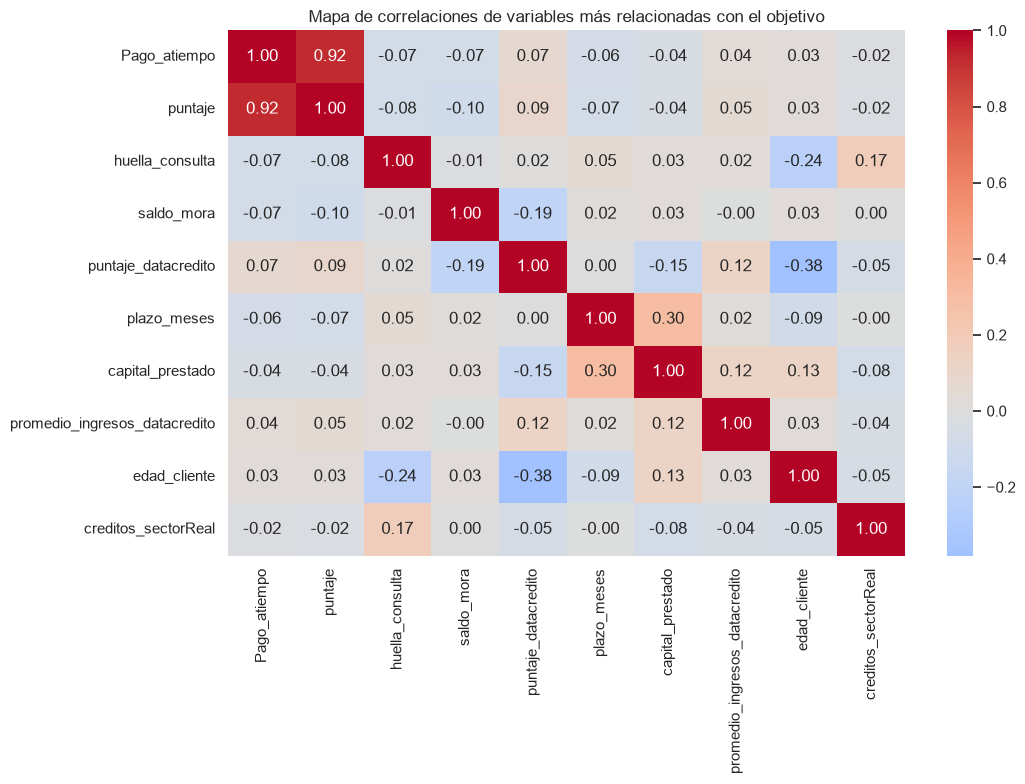

In [15]:
correlaciones = df.select_dtypes(include="number").corr()
variables_top = correlaciones["Pago_atiempo"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(11, 8))
sns.heatmap(df[variables_top].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de correlaciones de variables más relacionadas con el objetivo")
plt.tight_layout()
plt.show()

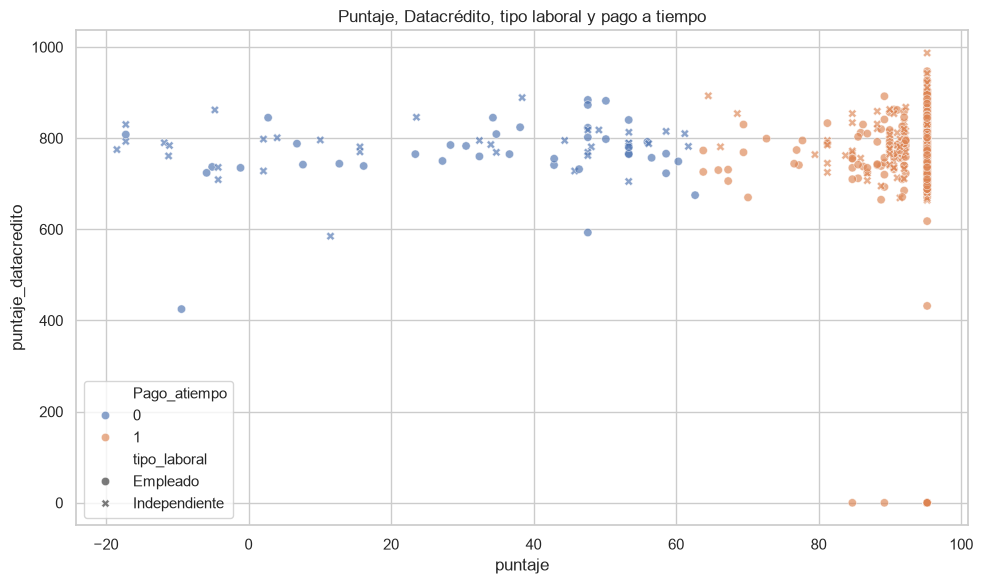

In [16]:
# Se toma una muestra para que el gráfico sea legible y rápido.
muestra = df.sample(n=min(1500, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=muestra,
    x="puntaje",
    y="puntaje_datacredito",
    hue="Pago_atiempo",
    style="tipo_laboral",
    alpha=0.65,
)
plt.title("Puntaje, Datacrédito, tipo laboral y pago a tiempo")
plt.tight_layout()
plt.show()

In [17]:
# Tasas por combinación de dos variables categóricas.
tabla_multi = pd.pivot_table(
    tendencias_validas,
    values="Pago_atiempo",
    index="tipo_laboral",
    columns="tendencia_ingresos",
    aggfunc=["count", "mean"],
)
tabla_multi

count                          mean                    
tendencia_ingresos Creciente Decreciente Estable Creciente Decreciente Estable
tipo_laboral                                                                  
Empleado                3843         937     646      0.96        0.94    0.96
Independiente           1451         354     542      0.95        0.93    0.95

## 5. Hallazgos y próximos pasos

1. **Desbalance del objetivo:** aproximadamente el 95% de los registros corresponde a pagos a tiempo. En modelado se necesitará división estratificada y métricas como recall, F1 y ROC-AUC, además de accuracy.
2. **Posible fuga de información:** `puntaje` presenta una relación extraordinariamente alta con `Pago_atiempo`. Antes de entrenar, debe confirmarse cuándo y cómo se calcula esa variable.
3. **Datos faltantes:** `tendencia_ingresos` y `promedio_ingresos_datacredito` concentran la mayor cantidad. La estrategia de imputación se decidirá en ingeniería de características.
4. **Inconsistencias a validar:** aparecen números en `tendencia_ingresos`, edades superiores a 100 años, salarios extremos y códigos de crédito muy poco frecuentes.
5. **Valores atípicos:** varias variables monetarias están muy sesgadas. No deben eliminarse sin entender primero si representan errores o clientes reales.
6. **Siguiente avance:** separar variables predictoras/objetivo, definir reglas de limpieza dentro de un pipeline y comparar modelos con validación adecuada.

Estos hallazgos son exploratorios: muestran asociaciones y alertas de calidad, no relaciones causales.